# When Does Horizon-Adaptive Channel Selection Help?

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.


In [1]:
from pathlib import Path
import gc
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2026
rng = np.random.default_rng(SEED)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 1.22.3
Pandas: 1.4.1


## 1. Experiment configuration


In [2]:
# ------------------------------------------------------------
# Screening configuration
# ------------------------------------------------------------
#
# This notebook is designed to be a scientifically controlled
# first-pass mechanism analysis, not a final full-source sweep.
#
# For very high-dimensional datasets, we sample target channels
# and use a broad source-candidate pool selected using TRAIN-ONLY
# current-value correlation. This keeps the experiment tractable
# while preserving the same protocol across datasets.
#
# If the mechanism is clear, a later notebook can rerun only the
# key datasets with more targets / all source channels.
# ------------------------------------------------------------

SEQ_LEN = 96

PEMS_HORIZONS = [12, 24, 48]
GENERAL_HORIZONS = [96, 192, 336, 720]

TOPK = 10

MAX_TARGET_CHANNELS = 32
MAX_SOURCE_CANDIDATES = 128

MAX_TRAIN_ORIGINS = 5000
MAX_TEST_ORIGINS = 3000

# Within official training data:
# first 70% -> fit teacher residual models
# final 30% -> score predictive utility
TEACHER_FIT_FRACTION = 0.70

RIDGE_LAMBDA = 1e-3
SOURCE_RIDGE_LAMBDA = 1e-2

PROJECT_ROOT = Path("/data/code/2026_08")
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_when_horizon_adaptive_selection_helps"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("OUTPUT_DIR:", OUTPUT_DIR)
print("TOPK:", TOPK)
print("MAX_TARGET_CHANNELS:", MAX_TARGET_CHANNELS)
print("MAX_SOURCE_CANDIDATES:", MAX_SOURCE_CANDIDATES)


OUTPUT_DIR: /data/code/2026_08/results_when_horizon_adaptive_selection_helps
TOPK: 10
MAX_TARGET_CHANNELS: 32
MAX_SOURCE_CANDIDATES: 128


## 2. Dataset registry


In [3]:
DATASET_REGISTRY = {
    "PeMS03": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS03.npz",
            "/data/dataset/PEMS03/PEMS03.npz",
            "/data/dataset/PEMS03.npz",
            "/data/dataset/pems/PeMS03.npz",
        ],
    },
    "PeMS04": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS04.npz",
            "/data/dataset/PEMS04/PEMS04.npz",
            "/data/dataset/PEMS04.npz",
            "/data/dataset/pems/PeMS04.npz",
        ],
    },
    "PeMS07": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS07.npz",
            "/data/dataset/PEMS07/PEMS07.npz",
            "/data/dataset/PEMS07.npz",
            "/data/dataset/pems/PeMS07.npz",
        ],
    },
    "PeMS08": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS08.npz",
            "/data/dataset/PEMS08/PEMS08.npz",
            "/data/dataset/PEMS08.npz",
            "/data/dataset/pems/PeMS08.npz",
        ],
    },
    "Electricity": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/electricity/electricity.csv",
            "/data/dataset/electricity.csv",
            "/data/dataset/ECL.csv",
        ],
    },
    "Weather": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/weather/weather.csv",
            "/data/dataset/weather.csv",
        ],
    },
    "Solar": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/solar/solar_AL.txt",
            "/data/dataset/solar_AL.txt",
            "/data/dataset/Solar/solar_AL.txt",
        ],
    },
    "ETTh1": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/ETT-small/ETTh1.csv",
            "/data/dataset/ETTh1.csv",
        ],
    },
    "ETTm1": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/ETT-small/ETTm1.csv",
            "/data/dataset/ETTm1.csv",
        ],
    },
}


def resolve_path(candidates):
    for p in candidates:
        p = Path(p)

        if p.exists():
            return p

    return None


resolved_rows = []

for name, spec in DATASET_REGISTRY.items():
    p = resolve_path(
        spec["paths"]
    )

    resolved_rows.append(
        {
            "dataset": name,
            "family": spec["family"],
            "path": (
                None
                if p is None
                else str(p)
            ),
            "found": (
                p is not None
            ),
            "horizons": str(
                spec["horizons"]
            ),
        }
    )

resolved_df = pd.DataFrame(
    resolved_rows
)

display(
    resolved_df
)

missing = resolved_df[
    ~resolved_df[
        "found"
    ]
]

if len(missing) > 0:
    print(
        "\nMissing datasets are listed above."
    )
    print(
        "Add the correct path to DATASET_REGISTRY before running the main experiment."
    )


,dataset,family,path,found,horizons
0,PeMS03,PeMS,/data/dataset/PeMS03.npz,True,"[12, 24, 48]"
1,PeMS04,PeMS,/data/dataset/PeMS04.npz,True,"[12, 24, 48]"
2,PeMS07,PeMS,/data/dataset/PeMS07.npz,True,"[12, 24, 48]"
3,PeMS08,PeMS,/data/dataset/PeMS08.npz,True,"[12, 24, 48]"
4,Electricity,General,/data/dataset/electricity/electricity.csv,True,"[96, 192, 336, 720]"
5,Weather,General,/data/dataset/weather/weather.csv,True,"[96, 192, 336, 720]"
6,Solar,General,/data/dataset/solar/solar_AL.txt,True,"[96, 192, 336, 720]"
7,ETTh1,General,/data/dataset/ETT-small/ETTh1.csv,True,"[96, 192, 336, 720]"
8,ETTm1,General,/data/dataset/ETT-small/ETTm1.csv,True,"[96, 192, 336, 720]"


## 3. Load raw series


In [4]:
def load_series(
    dataset_name,
    path,
):
    path = Path(path)

    if path.suffix.lower() == ".npz":
        obj = np.load(
            path
        )

        if "data" in obj:
            x = obj[
                "data"
            ]

        else:
            key = list(
                obj.keys()
            )[0]

            x = obj[
                key
            ]

        # Common PeMS format: [T, C, F].
        if x.ndim == 3:
            x = x[
                :,
                :,
                0,
            ]

        elif x.ndim != 2:
            raise ValueError(
                f"{dataset_name}: unexpected NPZ shape {x.shape}"
            )

        x = x.astype(
            np.float32
        )

    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(
            path
        )

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first = df.columns[
                0
            ]

            if not pd.api.types.is_numeric_dtype(
                df[
                    first
                ]
            ):
                date_col = first

        if date_col is not None:
            df = df.drop(
                columns=[
                    date_col
                ]
            )

        df = df.select_dtypes(
            include=[
                np.number
            ]
        )

        x = df.to_numpy(
            dtype=np.float32
        )

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )

        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[
                :,
                None
            ]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: expected [T,C], got {x.shape}"
        )

    if not np.isfinite(
        x
    ).all():
        # Simple interpolation-like fill is deliberately avoided.
        # Reject data so preprocessing remains explicit.
        raise ValueError(
            f"{dataset_name}: non-finite values detected"
        )

    return x


## 4. Official-like train/validation/test boundaries


In [5]:
def split_boundaries(
    dataset_name,
    T,
):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = train_end + 4 * 30 * 24
        test_end = val_end + 4 * 30 * 24

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    if dataset_name == "ETTm1":
        unit = 30 * 24 * 4

        train_end = 12 * unit
        val_end = train_end + 4 * unit
        test_end = val_end + 4 * unit

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    # Same broad protocol used in the previous cross-domain experiments.
    return (
        int(
            0.70 * T
        ),
        int(
            0.80 * T
        ),
        T,
    )


def standardize_train_only(
    x,
    train_end,
):
    mean = x[
        :train_end
    ].mean(
        axis=0,
        keepdims=True,
    )

    std = x[
        :train_end
    ].std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    return (
        (
            x - mean
        )
        /
        std
    ).astype(
        np.float32
    )


## 5. Forecast origins and summary features


In [6]:
def evenly_subsample(
    values,
    max_n,
):
    values = np.asarray(
        values,
        dtype=np.int64,
    )

    if len(
        values
    ) <= max_n:
        return values

    idx = np.linspace(
        0,
        len(
            values
        ) - 1,
        max_n,
        dtype=np.int64,
    )

    return values[
        idx
    ]


def make_origins(
    split_start,
    split_end,
    max_h,
    seq_len,
    max_n,
):
    first = max(
        seq_len,
        int(
            split_start
        ),
    )

    last = (
        int(
            split_end
        )
        -
        int(
            max_h
        )
    )

    if last < first:
        raise RuntimeError(
            f"No valid origins: start={first}, end={last}"
        )

    origins = np.arange(
        first,
        last + 1,
        dtype=np.int64,
    )

    return evenly_subsample(
        origins,
        max_n,
    )


def summary_features(
    x,
    origins,
):
    """
    Returns [N,C,4]:
      last
      mean3
      mean12
      delta12
    """
    origins = np.asarray(
        origins,
        dtype=np.int64,
    )

    last = x[
        origins - 1
    ]

    mean3 = np.stack(
        [
            x[
                t-3:
                t
            ].mean(
                axis=0
            )
            for t in origins
        ],
        axis=0,
    )

    mean12 = np.stack(
        [
            x[
                t-12:
                t
            ].mean(
                axis=0
            )
            for t in origins
        ],
        axis=0,
    )

    delta12 = (
        x[
            origins - 1
        ]
        -
        x[
            origins - 12
        ]
    )

    return np.stack(
        [
            last,
            mean3,
            mean12,
            delta12,
        ],
        axis=-1,
    ).astype(
        np.float32
    )


## 6. Ridge helpers


In [7]:
def add_bias_column(
    X,
):
    return np.concatenate(
        [
            np.ones(
                (
                    len(
                        X
                    ),
                    1,
                ),
                dtype=np.float32,
            ),
            X.astype(
                np.float32
            ),
        ],
        axis=1,
    )


def ridge_fit(
    X,
    y,
    lam=RIDGE_LAMBDA,
):
    Xb = add_bias_column(
        X
    )

    p = Xb.shape[
        1
    ]

    reg = np.eye(
        p,
        dtype=np.float64,
    )

    # Do not regularize intercept.
    reg[
        0,
        0
    ] = 0.0

    A = (
        Xb.T
        @
        Xb
    ).astype(
        np.float64
    )

    b = (
        Xb.T
        @
        y
    ).astype(
        np.float64
    )

    beta = np.linalg.solve(
        A
        +
        lam
        *
        reg,
        b,
    )

    return beta


def ridge_predict(
    X,
    beta,
):
    return (
        add_bias_column(
            X
        )
        @
        beta
    ).astype(
        np.float32
    )


def fit_and_mse(
    X_train,
    y_train,
    X_test,
    y_test,
    lam=RIDGE_LAMBDA,
):
    beta = ridge_fit(
        X_train,
        y_train,
        lam=lam,
    )

    pred = ridge_predict(
        X_test,
        beta,
    )

    return float(
        np.mean(
            (
                y_test
                -
                pred
            )
            **
            2
        )
    )


## 7. Candidate-source pool from TRAIN-ONLY correlation


In [8]:
def choose_targets(
    C,
):
    if C <= MAX_TARGET_CHANNELS:
        return np.arange(
            C,
            dtype=np.int64,
        )

    # Deterministic coverage across the channel index range.
    return np.unique(
        np.linspace(
            0,
            C - 1,
            MAX_TARGET_CHANNELS,
            dtype=np.int64,
        )
    )


def source_candidate_map(
    train_features,
    targets,
):
    """
    Use TRAIN-ONLY current-value correlation to define a broad,
    horizon-INVARIANT candidate pool.

    The pool is only a computational screening device.
    Horizon-specific selection happens later using predictive utility.
    """
    current = train_features[
        :,
        :,
        0,
    ].astype(
        np.float64
    )

    current = (
        current
        -
        current.mean(
            axis=0,
            keepdims=True,
        )
    )

    denom = np.sqrt(
        np.sum(
            current
            *
            current,
            axis=0,
        )
    )

    denom = np.maximum(
        denom,
        1e-12,
    )

    normed = (
        current
        /
        denom[
            None,
            :
        ]
    )

    result = {}

    C = current.shape[
        1
    ]

    pool_size = min(
        MAX_SOURCE_CANDIDATES,
        max(
            1,
            C - 1,
        ),
    )

    for i in targets:
        corr = (
            normed[
                :,
                i
            ]
            @
            normed
        )

        corr = np.abs(
            corr
        )

        corr[
            i
        ] = -np.inf

        idx = np.argpartition(
            corr,
            -pool_size,
        )[
            -pool_size:
        ]

        idx = idx[
            np.argsort(
                corr[
                    idx
                ]
            )[
                ::-1
            ]
        ]

        result[
            int(
                i
            )
        ] = idx.astype(
            np.int64
        )

    return result


## 8. Vectorized Predictive-Utility Teacher for one target/horizon


In [9]:
def _safe_topk_indices(
    scores,
    k,
):
    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    k = min(
        int(
            k
        ),
        len(
            scores
        ),
    )

    if k <= 0:
        return np.array(
            [],
            dtype=np.int64,
        )

    idx = np.argpartition(
        scores,
        -k,
    )[
        -k:
    ]

    return idx[
        np.argsort(
            scores[
                idx
            ]
        )[
            ::-1
        ]
    ]


def _jaccard(
    a,
    b,
):
    a = set(
        np.asarray(
            a
        ).tolist()
    )

    b = set(
        np.asarray(
            b
        ).tolist()
    )

    if len(
        a | b
    ) == 0:
        return 1.0

    return (
        len(
            a & b
        )
        /
        len(
            a | b
        )
    )


def predictive_utility_for_target(
    X_train_all,
    y_train,
    target_idx,
    source_ids,
):
    """
    Training-only teacher.

    X_train_all: [N,C,4]
    y_train:      [N]

    Steps:
      1) chronologically split official train origins into fit/score
      2) fit target-only baseline on target features
      3) residualize every source's 4 features against target features
      4) fit marginal residual correction for all sources in batched 4x4 solves
      5) score utility on held-out teacher-score segment
      6) compute source-set reliability by scoring the same fitted corrections
         on first/second halves of teacher-score segment
    """
    N = X_train_all.shape[
        0
    ]

    split = int(
        TEACHER_FIT_FRACTION
        *
        N
    )

    split = min(
        max(
            split,
            32,
        ),
        N - 16,
    )

    fit_idx = np.arange(
        0,
        split,
        dtype=np.int64,
    )

    score_idx = np.arange(
        split,
        N,
        dtype=np.int64,
    )

    Xt = X_train_all[
        :,
        target_idx,
        :
    ].astype(
        np.float64
    )

    U = X_train_all[
        :,
        source_ids,
        :
    ].astype(
        np.float64
    )

    y = y_train.astype(
        np.float64
    )

    # --------------------------------------------------------
    # Target-only baseline.
    # --------------------------------------------------------
    beta_t = ridge_fit(
        Xt[
            fit_idx
        ],
        y[
            fit_idx
        ],
        lam=RIDGE_LAMBDA,
    )

    pred_fit = ridge_predict(
        Xt[
            fit_idx
        ],
        beta_t,
    ).astype(
        np.float64
    )

    pred_score = ridge_predict(
        Xt[
            score_idx
        ],
        beta_t,
    ).astype(
        np.float64
    )

    r_fit = (
        y[
            fit_idx
        ]
        -
        pred_fit
    )

    r_score = (
        y[
            score_idx
        ]
        -
        pred_score
    )

    base_mse = float(
        np.mean(
            r_score
            *
            r_score
        )
    )

    # --------------------------------------------------------
    # Residualize all source features against target history.
    #
    # Multi-output regression:
    #   source_features ~ target_features
    #
    # This prevents utility from simply reflecting information
    # already present in the target channel.
    # --------------------------------------------------------
    Xt_fit_b = add_bias_column(
        Xt[
            fit_idx
        ]
    ).astype(
        np.float64
    )

    Xt_score_b = add_bias_column(
        Xt[
            score_idx
        ]
    ).astype(
        np.float64
    )

    U_fit = U[
        fit_idx
    ]

    U_score = U[
        score_idx
    ]

    S = U_fit.shape[
        1
    ]

    Fdim = U_fit.shape[
        2
    ]

    U_fit_flat = U_fit.reshape(
        len(
            fit_idx
        ),
        S
        *
        Fdim,
    )

    A = (
        Xt_fit_b.T
        @
        Xt_fit_b
    )

    reg = np.eye(
        A.shape[
            0
        ],
        dtype=np.float64,
    )

    reg[
        0,
        0
    ] = 0.0

    coef_u = np.linalg.solve(
        A
        +
        RIDGE_LAMBDA
        *
        reg,
        Xt_fit_b.T
        @
        U_fit_flat,
    )

    U_fit_res = (
        U_fit_flat
        -
        Xt_fit_b
        @
        coef_u
    ).reshape(
        len(
            fit_idx
        ),
        S,
        Fdim,
    )

    U_score_flat = U_score.reshape(
        len(
            score_idx
        ),
        S
        *
        Fdim,
    )

    U_score_res = (
        U_score_flat
        -
        Xt_score_b
        @
        coef_u
    ).reshape(
        len(
            score_idx
        ),
        S,
        Fdim,
    )

    # --------------------------------------------------------
    # Batched marginal residual correction for every source.
    # --------------------------------------------------------
    gram = np.einsum(
        "nsf,nsg->sfg",
        U_fit_res,
        U_fit_res,
    )

    cross = np.einsum(
        "nsf,n->sf",
        U_fit_res,
        r_fit,
    )

    eye = np.eye(
        Fdim,
        dtype=np.float64,
    )[
        None,
        :,
        :
    ]

    beta_s = np.linalg.solve(
        gram
        +
        SOURCE_RIDGE_LAMBDA
        *
        eye,
        cross[
            :,
            :,
            None
        ],
    )[
        :,
        :,
        0
    ]

    pred_res_score = np.einsum(
        "nsf,sf->ns",
        U_score_res,
        beta_s,
    )

    err = (
        r_score[
            :,
            None
        ]
        -
        pred_res_score
    )

    mse_source = np.mean(
        err
        *
        err,
        axis=0,
    )

    utility = (
        100.0
        *
        (
            base_mse
            -
            mse_source
        )
        /
        max(
            base_mse,
            1e-12,
        )
    )

    # --------------------------------------------------------
    # Reliability: score same fitted marginal models on the two
    # chronological halves of the teacher-score segment.
    # --------------------------------------------------------
    n_score = len(
        score_idx
    )

    mid = max(
        1,
        n_score // 2,
    )

    def utility_slice(
        start,
        end,
    ):
        rr = r_score[
            start:
            end
        ]

        pp = pred_res_score[
            start:
            end
        ]

        if len(
            rr
        ) == 0:
            return utility.copy()

        base = np.mean(
            rr
            *
            rr
        )

        mse = np.mean(
            (
                rr[
                    :,
                    None
                ]
                -
                pp
            )
            **
            2,
            axis=0,
        )

        return (
            100.0
            *
            (
                base
                -
                mse
            )
            /
            max(
                base,
                1e-12,
            )
        )

    utility_first = utility_slice(
        0,
        mid,
    )

    utility_second = utility_slice(
        mid,
        n_score,
    )

    return {
        "source_ids": np.asarray(
            source_ids,
            dtype=np.int64,
        ),
        "utility": utility.astype(
            np.float32
        ),
        "utility_first": utility_first.astype(
            np.float32
        ),
        "utility_second": utility_second.astype(
            np.float32
        ),
        "teacher_base_mse": base_mse,
    }


## 9. Final controlled forecaster: Shared vs Horizon-Adaptive source set


In [10]:
def feature_matrix_for_sources(
    X_all,
    target_idx,
    source_ids,
):
    target = X_all[
        :,
        target_idx,
        :
    ]

    if len(
        source_ids
    ) == 0:
        return target

    source = X_all[
        :,
        source_ids,
        :
    ].reshape(
        len(
            X_all
        ),
        -1,
    )

    return np.concatenate(
        [
            target,
            source,
        ],
        axis=1,
    )


def selected_forecast_mse(
    X_train_all,
    y_train,
    X_test_all,
    y_test,
    target_idx,
    source_ids,
):
    Xtr = feature_matrix_for_sources(
        X_train_all,
        target_idx,
        source_ids,
    )

    Xte = feature_matrix_for_sources(
        X_test_all,
        target_idx,
        source_ids,
    )

    return fit_and_mse(
        Xtr,
        y_train,
        Xte,
        y_test,
        lam=RIDGE_LAMBDA,
    )


## 10. Analyze one dataset


In [11]:
def analyze_dataset(
    dataset_name,
    spec,
):
    t0 = time.time()

    path = resolve_path(
        spec[
            "paths"
        ]
    )

    if path is None:
        raise FileNotFoundError(
            f"{dataset_name}: dataset path not found"
        )

    raw = load_series(
        dataset_name,
        path,
    )

    T, C = raw.shape

    horizons = list(
        spec[
            "horizons"
        ]
    )

    max_h = max(
        horizons
    )

    (
        train_end,
        val_end,
        test_end,
    ) = split_boundaries(
        dataset_name,
        T,
    )

    x = standardize_train_only(
        raw,
        train_end,
    )

    train_origins = make_origins(
        split_start=SEQ_LEN,
        split_end=train_end,
        max_h=max_h,
        seq_len=SEQ_LEN,
        max_n=MAX_TRAIN_ORIGINS,
    )

    test_origins = make_origins(
        split_start=val_end,
        split_end=test_end,
        max_h=max_h,
        seq_len=SEQ_LEN,
        max_n=MAX_TEST_ORIGINS,
    )

    X_train = summary_features(
        x,
        train_origins,
    )

    X_test = summary_features(
        x,
        test_origins,
    )

    targets = choose_targets(
        C
    )

    candidate_map = source_candidate_map(
        X_train,
        targets,
    )

    rows = []

    # Cache utility per target and horizon first so shared selection
    # is defined using all horizons.
    target_teacher_cache = {}

    for ti, target_idx in enumerate(
        targets
    ):
        source_ids = candidate_map[
            int(
                target_idx
            )
        ]

        utility_by_h = {}

        for h in horizons:
            y_train = x[
                train_origins
                +
                h
                -
                1,
                target_idx,
            ]

            teacher = predictive_utility_for_target(
                X_train,
                y_train,
                int(
                    target_idx
                ),
                source_ids,
            )

            utility_by_h[
                int(
                    h
                )
            ] = teacher

        target_teacher_cache[
            int(
                target_idx
            )
        ] = utility_by_h

        if (
            (ti + 1)
            %
            max(
                1,
                len(
                    targets
                )
                //
                4,
            )
            ==
            0
        ):
            print(
                f"  teacher {ti+1}/{len(targets)} targets"
            )

    # --------------------------------------------------------
    # Shared source set: mean predictive utility across horizons.
    # --------------------------------------------------------
    for ti, target_idx in enumerate(
        targets
    ):
        utility_by_h = target_teacher_cache[
            int(
                target_idx
            )
        ]

        source_ids = utility_by_h[
            horizons[
                0
            ]
        ][
            "source_ids"
        ]

        utility_stack = np.stack(
            [
                utility_by_h[
                    h
                ][
                    "utility"
                ]
                for h in horizons
            ],
            axis=0,
        )

        shared_utility = utility_stack.mean(
            axis=0
        )

        shared_local = _safe_topk_indices(
            shared_utility,
            TOPK,
        )

        shared_sources = source_ids[
            shared_local
        ]

        # Shortest-horizon adaptive source set for drift reference.
        short_teacher = utility_by_h[
            horizons[
                0
            ]
        ]

        short_local = _safe_topk_indices(
            short_teacher[
                "utility"
            ],
            TOPK,
        )

        short_sources = source_ids[
            short_local
        ]

        for h in horizons:
            teacher = utility_by_h[
                h
            ]

            utility = teacher[
                "utility"
            ]

            adaptive_local = _safe_topk_indices(
                utility,
                TOPK,
            )

            adaptive_sources = source_ids[
                adaptive_local
            ]

            first_local = _safe_topk_indices(
                teacher[
                    "utility_first"
                ],
                TOPK,
            )

            second_local = _safe_topk_indices(
                teacher[
                    "utility_second"
                ],
                TOPK,
            )

            first_sources = source_ids[
                first_local
            ]

            second_sources = source_ids[
                second_local
            ]

            drift = (
                1.0
                -
                _jaccard(
                    short_sources,
                    adaptive_sources,
                )
            )

            reliability = _jaccard(
                first_sources,
                second_sources,
            )

            top_utility = utility[
                adaptive_local
            ]

            top_utility_mean = float(
                np.mean(
                    top_utility
                )
            )

            positive = np.clip(
                utility,
                0.0,
                None,
            )

            concentration = float(
                np.sum(
                    positive[
                        adaptive_local
                    ]
                )
                /
                max(
                    np.sum(
                        positive
                    ),
                    1e-12,
                )
            )

            y_train = x[
                train_origins
                +
                h
                -
                1,
                target_idx,
            ]

            y_test = x[
                test_origins
                +
                h
                -
                1,
                target_idx,
            ]

            target_only_mse = (
                selected_forecast_mse(
                    X_train,
                    y_train,
                    X_test,
                    y_test,
                    int(
                        target_idx
                    ),
                    [],
                )
            )

            shared_mse = (
                selected_forecast_mse(
                    X_train,
                    y_train,
                    X_test,
                    y_test,
                    int(
                        target_idx
                    ),
                    shared_sources,
                )
            )

            adaptive_mse = (
                selected_forecast_mse(
                    X_train,
                    y_train,
                    X_test,
                    y_test,
                    int(
                        target_idx
                    ),
                    adaptive_sources,
                )
            )

            headroom = (
                100.0
                *
                (
                    target_only_mse
                    -
                    adaptive_mse
                )
                /
                max(
                    target_only_mse,
                    1e-12,
                )
            )

            adaptive_gain = (
                100.0
                *
                (
                    shared_mse
                    -
                    adaptive_mse
                )
                /
                max(
                    shared_mse,
                    1e-12,
                )
            )

            rows.append(
                {
                    "dataset": dataset_name,
                    "family": spec[
                        "family"
                    ],
                    "T": T,
                    "C": C,
                    "target_channel": int(
                        target_idx
                    ),
                    "horizon": int(
                        h
                    ),

                    "dependency_drift": float(
                        drift
                    ),
                    "predictive_utility_topk_mean_%": (
                        top_utility_mean
                    ),
                    "utility_concentration": (
                        concentration
                    ),
                    "source_reliability": float(
                        reliability
                    ),

                    "target_only_test_mse": (
                        target_only_mse
                    ),
                    "shared_test_mse": (
                        shared_mse
                    ),
                    "adaptive_test_mse": (
                        adaptive_mse
                    ),

                    "cross_channel_headroom_%": (
                        headroom
                    ),
                    "adaptive_gain_vs_shared_%": (
                        adaptive_gain
                    ),

                    "shared_sources": (
                        ",".join(
                            map(
                                str,
                                shared_sources.tolist(),
                            )
                        )
                    ),
                    "adaptive_sources": (
                        ",".join(
                            map(
                                str,
                                adaptive_sources.tolist(),
                            )
                        )
                    ),
                }
            )

        if (
            (ti + 1)
            %
            max(
                1,
                len(
                    targets
                )
                //
                4,
            )
            ==
            0
        ):
            print(
                f"  forecast {ti+1}/{len(targets)} targets"
            )

    df = pd.DataFrame(
        rows
    )

    out_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_mechanism_rows.csv"
    )

    df.to_csv(
        out_path,
        index=False,
    )

    print(
        f"{dataset_name}: "
        f"rows={len(df)}, "
        f"C={C}, "
        f"targets={len(targets)}, "
        f"time={time.time()-t0:.1f}s"
    )

    return df


## 11. Run all datasets with resume


In [12]:
all_frames = []
failures = []

for dataset_name, spec in DATASET_REGISTRY.items():
    print(
        "\n"
        +
        "="
        *
        100
    )

    print(
        dataset_name
    )

    print(
        "="
        *
        100
    )

    saved = (
        OUTPUT_DIR
        /
        f"{dataset_name}_mechanism_rows.csv"
    )

    if saved.exists():
        print(
            "Reusing:",
            saved
        )

        df = pd.read_csv(
            saved
        )

        all_frames.append(
            df
        )

        continue

    try:
        df = analyze_dataset(
            dataset_name,
            spec,
        )

        all_frames.append(
            df
        )

    except Exception as e:
        failures.append(
            {
                "dataset": dataset_name,
                "error": repr(
                    e
                ),
            }
        )

        print(
            "FAILED:",
            repr(
                e
            )
        )

    gc.collect()

if len(
    all_frames
) == 0:
    raise RuntimeError(
        "No dataset completed."
    )

all_rows = pd.concat(
    all_frames,
    ignore_index=True,
)

all_rows.to_csv(
    OUTPUT_DIR
    / "mechanism_target_horizon_rows.csv",
    index=False,
)

failure_df = pd.DataFrame(
    failures
)

failure_df.to_csv(
    OUTPUT_DIR
    / "mechanism_failures.csv",
    index=False,
)

print(
    "\nCompleted datasets:",
    all_rows[
        "dataset"
    ].nunique(),
    "/",
    len(
        DATASET_REGISTRY
    ),
)

print(
    "Rows:",
    len(
        all_rows
    ),
)

print(
    "Failures:",
    len(
        failures
    ),
)

if failures:
    display(
        failure_df
    )



PeMS03
  teacher 8/32 targets
  teacher 16/32 targets
  teacher 24/32 targets
  teacher 32/32 targets
  forecast 8/32 targets
  forecast 16/32 targets
  forecast 24/32 targets
  forecast 32/32 targets
PeMS03: rows=96, C=358, targets=32, time=9.9s

PeMS04
  teacher 8/32 targets
  teacher 16/32 targets
  teacher 24/32 targets
  teacher 32/32 targets
  forecast 8/32 targets
  forecast 16/32 targets
  forecast 24/32 targets
  forecast 32/32 targets
PeMS04: rows=96, C=307, targets=32, time=10.4s

PeMS07
  teacher 8/32 targets
  teacher 16/32 targets
  teacher 24/32 targets
  teacher 32/32 targets
  forecast 8/32 targets
  forecast 16/32 targets
  forecast 24/32 targets
  forecast 32/32 targets
PeMS07: rows=96, C=883, targets=32, time=13.9s

PeMS08
  teacher 8/32 targets
  teacher 16/32 targets
  teacher 24/32 targets
  teacher 32/32 targets
  forecast 8/32 targets
  forecast 16/32 targets
  forecast 24/32 targets
  forecast 32/32 targets
PeMS08: rows=96, C=170, targets=32, time=12.4s

Elec

## 12. Aggregate to dataset × horizon conditions


In [13]:
metric_cols = [
    "dependency_drift",
    "predictive_utility_topk_mean_%",
    "utility_concentration",
    "source_reliability",
    "target_only_test_mse",
    "cross_channel_headroom_%",
    "adaptive_gain_vs_shared_%",
]

condition_mean = (
    all_rows
    .groupby(
        [
            "family",
            "dataset",
            "horizon",
        ],
        as_index=False,
    )[
        metric_cols
    ]
    .mean()
)

condition_median = (
    all_rows
    .groupby(
        [
            "family",
            "dataset",
            "horizon",
        ],
        as_index=False,
    )[
        metric_cols
    ]
    .median()
)

condition_mean.to_csv(
    OUTPUT_DIR
    / "mechanism_condition_mean.csv",
    index=False,
)

condition_median.to_csv(
    OUTPUT_DIR
    / "mechanism_condition_median.csv",
    index=False,
)

display(
    condition_mean.round(
        4
    )
)


,family,dataset,horizon,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,target_only_test_mse,cross_channel_headroom_%,adaptive_gain_vs_shared_%
0,General,ETTh1,96,0.0000,-1.5804,1.0000,1.0000,0.4933,-48.8841,0.0000
1,General,ETTh1,192,0.0000,-3.3029,0.8571,1.0000,0.5267,-95.8237,0.0000
2,General,ETTh1,336,0.0000,-5.4677,1.0000,1.0000,0.5413,-148.7682,-0.0000
3,General,ETTh1,720,0.0000,-5.0371,0.8571,1.0000,0.6933,-190.4719,-0.0000
4,General,ETTm1,96,0.0000,-2.8645,0.8571,1.0000,0.3672,-42.3661,0.0000
5,General,ETTm1,192,0.0000,-0.7773,1.0000,1.0000,0.4080,-25.1319,0.0000
6,General,ETTm1,336,0.0000,-1.0411,1.0000,1.0000,0.8170,-65.7456,0.0000
7,General,ETTm1,720,0.0000,0.5945,1.0000,1.0000,0.8154,-87.0147,0.0000
8,General,Electricity,96,0.0000,9.3572,0.2377,0.1235,0.2998,3.9177,-2.0016
9,General,Electricity,192,0.6031,7.2979,0.2610,0.1113,0.2761,6.9101,-0.3444


## 13. The first decisive question: PeMS vs general datasets


In [14]:
family_summary = (
    condition_mean
    .groupby(
        "family",
        as_index=False,
    )
    [
        [
            "dependency_drift",
            "predictive_utility_topk_mean_%",
            "utility_concentration",
            "source_reliability",
            "cross_channel_headroom_%",
            "adaptive_gain_vs_shared_%",
        ]
    ]
    .mean()
)

display(
    family_summary.round(
        4
    )
)

for family in [
    "PeMS",
    "General",
]:
    sub = condition_mean[
        condition_mean[
            "family"
        ]
        ==
        family
    ]

    if len(
        sub
    ) == 0:
        continue

    print(
        f"\n{family}: "
        f"positive adaptive conditions = "
        f"{int((sub['adaptive_gain_vs_shared_%'] > 0).sum())}"
        f"/{len(sub)}, "
        f"mean gain="
        f"{sub['adaptive_gain_vs_shared_%'].mean():+.3f}%"
    )


,family,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,cross_channel_headroom_%,adaptive_gain_vs_shared_%
0,General,0.2433,4.3191,0.6606,0.6289,-35.5338,-0.4506
1,PeMS,0.5009,28.2306,0.1688,0.4277,-273.8264,-607.3229



PeMS: positive adaptive conditions = 4/12, mean gain=-607.323%

General: positive adaptive conditions = 5/20, mean gain=-0.451%


## 14. Spearman relationships


In [15]:
def spearman_matrix(
    df,
    columns,
):
    return (
        df[
            columns
        ]
        .corr(
            method="spearman"
        )
    )


analysis_cols = [
    "dependency_drift",
    "predictive_utility_topk_mean_%",
    "utility_concentration",
    "source_reliability",
    "target_only_test_mse",
    "cross_channel_headroom_%",
    "adaptive_gain_vs_shared_%",
]

print(
    "=== Condition-level, all datasets ==="
)

display(
    spearman_matrix(
        condition_mean,
        analysis_cols,
    ).round(
        3
    )
)

print(
    "=== PeMS only ==="
)

display(
    spearman_matrix(
        condition_mean[
            condition_mean[
                "family"
            ]
            ==
            "PeMS"
        ],
        analysis_cols,
    ).round(
        3
    )
)

print(
    "=== General datasets only ==="
)

display(
    spearman_matrix(
        condition_mean[
            condition_mean[
                "family"
            ]
            ==
            "General"
        ],
        analysis_cols,
    ).round(
        3
    )
)


=== Condition-level, all datasets ===


,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,target_only_test_mse,cross_channel_headroom_%,adaptive_gain_vs_shared_%
dependency_drift,1.000,0.462,-0.441,-0.525,0.197,0.515,-0.002
predictive_utility_topk_mean_%,0.462,1.000,-0.810,-0.563,-0.268,0.797,-0.161
utility_concentration,-0.441,-0.810,1.000,0.627,0.248,-0.727,0.107
source_reliability,-0.525,-0.563,0.627,1.000,0.435,-0.546,0.317
target_only_test_mse,0.197,-0.268,0.248,0.435,1.000,-0.195,0.141
cross_channel_headroom_%,0.515,0.797,-0.727,-0.546,-0.195,1.000,0.011
adaptive_gain_vs_shared_%,-0.002,-0.161,0.107,0.317,0.141,0.011,1.000


=== PeMS only ===


,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,target_only_test_mse,cross_channel_headroom_%,adaptive_gain_vs_shared_%
dependency_drift,1.000,-0.121,0.178,0.078,0.868,0.014,0.103
predictive_utility_topk_mean_%,-0.121,1.000,-0.909,0.210,-0.147,0.804,0.748
utility_concentration,0.178,-0.909,1.000,-0.168,0.343,-0.580,-0.594
source_reliability,0.078,0.210,-0.168,1.000,0.224,0.462,0.238
target_only_test_mse,0.868,-0.147,0.343,0.224,1.000,0.203,0.126
cross_channel_headroom_%,0.014,0.804,-0.580,0.462,0.203,1.000,0.790
adaptive_gain_vs_shared_%,0.103,0.748,-0.594,0.238,0.126,0.790,1.000


=== General datasets only ===


,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,target_only_test_mse,cross_channel_headroom_%,adaptive_gain_vs_shared_%
dependency_drift,1.000,0.546,-0.504,-0.769,-0.395,0.678,-0.114
predictive_utility_topk_mean_%,0.546,1.000,-0.467,-0.744,-0.450,0.824,-0.370
utility_concentration,-0.504,-0.467,1.000,0.733,0.243,-0.729,0.383
source_reliability,-0.769,-0.744,0.733,1.000,0.498,-0.923,0.521
target_only_test_mse,-0.395,-0.450,0.243,0.498,1.000,-0.496,0.120
cross_channel_headroom_%,0.678,0.824,-0.729,-0.923,-0.496,1.000,-0.435
adaptive_gain_vs_shared_%,-0.114,-0.370,0.383,0.521,0.120,-0.435,1.000


## 15. Does drift need headroom / utility to become useful?


In [16]:
# Use robust condition-level median thresholds.
df = condition_mean.copy()

for col in [
    "dependency_drift",
    "predictive_utility_topk_mean_%",
    "utility_concentration",
    "source_reliability",
    "cross_channel_headroom_%",
]:
    threshold = df[
        col
    ].median()

    df[
        f"high_{col}"
    ] = (
        df[
            col
        ]
        >=
        threshold
    )

# Simple interpretable conjunctions.
df[
    "high_drift_and_headroom"
] = (
    df[
        "high_dependency_drift"
    ]
    &
    df[
        "high_cross_channel_headroom_%"
    ]
)

df[
    "high_drift_utility_concentration"
] = (
    df[
        "high_dependency_drift"
    ]
    &
    df[
        "high_predictive_utility_topk_mean_%"
    ]
    &
    df[
        "high_utility_concentration"
    ]
)

df[
    "high_all_exploitability"
] = (
    df[
        "high_dependency_drift"
    ]
    &
    df[
        "high_predictive_utility_topk_mean_%"
    ]
    &
    df[
        "high_utility_concentration"
    ]
    &
    df[
        "high_source_reliability"
    ]
    &
    df[
        "high_cross_channel_headroom_%"
    ]
)


def summarize_binary_group(
    df,
    flag,
):
    return (
        df
        .groupby(
            flag
        )[
            "adaptive_gain_vs_shared_%"
        ]
        .agg(
            [
                "count",
                "mean",
                "median",
            ]
        )
    )


for flag in [
    "high_dependency_drift",
    "high_drift_and_headroom",
    "high_drift_utility_concentration",
    "high_all_exploitability",
]:
    print(
        "\n",
        flag
    )

    display(
        summarize_binary_group(
            df,
            flag,
        ).round(
            4
        )
    )



 high_dependency_drift


,count,mean,median
high_dependency_drift,,,
False,16,-453.2909,-0.0000
True,16,-2.7646,-0.4684



 high_drift_and_headroom


,count,mean,median
high_drift_and_headroom,,,
False,21,-347.1574,-0.0626
True,11,-0.5985,-0.4590



 high_drift_utility_concentration


,count,mean,median
high_drift_utility_concentration,,,
False,31,-235.3681,-0.0725
True,1,-0.4778,-0.4778



 high_all_exploitability


,count,mean,median
high_all_exploitability,,,
False,32,-228.0278,-0.2085


## 16. Exploratory exploitable-shift score


In [17]:
def percentile_rank(
    x,
):
    return (
        pd.Series(
            x
        )
        .rank(
            pct=True,
            method="average",
        )
        .to_numpy()
    )


score_df = condition_mean.copy()

D = percentile_rank(
    score_df[
        "dependency_drift"
    ]
)

U = percentile_rank(
    score_df[
        "predictive_utility_topk_mean_%"
    ]
)

C = percentile_rank(
    score_df[
        "utility_concentration"
    ]
)

R = percentile_rank(
    score_df[
        "source_reliability"
    ]
)

Hc = percentile_rank(
    score_df[
        "cross_channel_headroom_%"
    ]
)

# Exploratory only.
# A multiplicative score encodes the hypothesis that all ingredients
# must be simultaneously present.
score_df[
    "exploitable_shift_score"
] = (
    D
    *
    U
    *
    C
    *
    R
    *
    Hc
)

rho = (
    score_df[
        [
            "exploitable_shift_score",
            "adaptive_gain_vs_shared_%",
        ]
    ]
    .corr(
        method="spearman"
    )
    .iloc[
        0,
        1
    ]
)

print(
    "Spearman(exploitable_shift, adaptive_gain) =",
    round(
        float(
            rho
        ),
        3,
    )
)

display(
    score_df[
        [
            "family",
            "dataset",
            "horizon",
            "exploitable_shift_score",
            "adaptive_gain_vs_shared_%",
            "dependency_drift",
            "predictive_utility_topk_mean_%",
            "utility_concentration",
            "source_reliability",
            "cross_channel_headroom_%",
        ]
    ]
    .sort_values(
        "exploitable_shift_score",
        ascending=False,
    )
    .round(
        4
    )
)

score_df.to_csv(
    OUTPUT_DIR
    / "mechanism_exploitable_shift.csv",
    index=False,
)


Spearman(exploitable_shift, adaptive_gain) = -0.099


,family,dataset,horizon,exploitable_shift_score,adaptive_gain_vs_shared_%,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,cross_channel_headroom_%
25,PeMS,PeMS04,48,0.1089,12.4078,0.8355,31.8638,0.1675,0.4855,54.6713
22,PeMS,PeMS03,48,0.1084,-14.1890,0.9027,23.6215,0.1699,0.5349,29.1787
21,PeMS,PeMS03,24,0.0760,-3.9862,0.5400,26.8543,0.1685,0.5541,34.9847
31,PeMS,PeMS08,48,0.0521,9.2593,0.9223,30.1975,0.1614,0.4815,32.8787
17,General,Weather,192,0.0513,-0.0725,0.2566,9.6436,0.9344,0.6264,-24.5346
18,General,Weather,336,0.0482,0.7035,0.3201,8.6905,0.9154,0.6159,-20.0356
16,General,Weather,96,0.0396,-3.1082,0.0000,12.7412,0.9426,0.6682,-1.5968
19,General,Weather,720,0.0395,-0.0626,0.4689,4.5852,0.9616,0.5760,-2.7137
24,PeMS,PeMS04,24,0.0353,-1.5881,0.5542,32.7089,0.1600,0.4789,44.8469
27,PeMS,PeMS07,24,0.0314,-8.5516,0.6663,24.0590,0.1775,0.3178,8.2656


## 17. Scatter plots


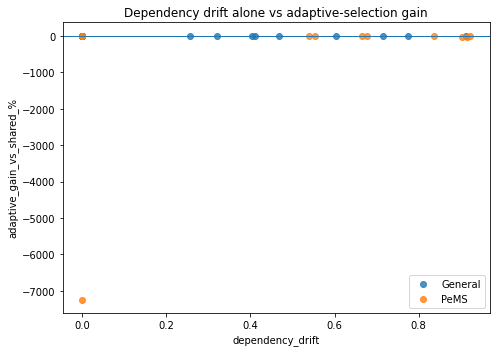

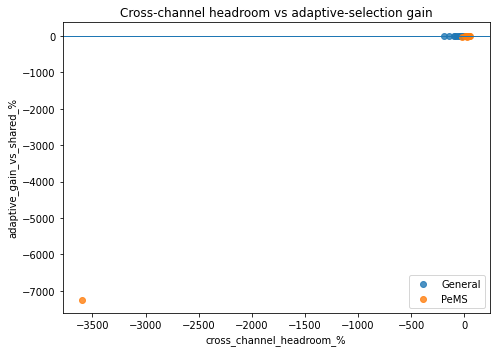

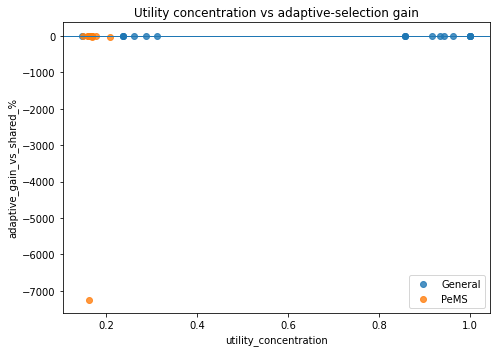

In [18]:
def scatter_metric(
    x_col,
    y_col,
    title,
):
    fig, ax = plt.subplots(
        figsize=(
            7,
            5,
        )
    )

    for family, sub in condition_mean.groupby(
        "family"
    ):
        ax.scatter(
            sub[
                x_col
            ],
            sub[
                y_col
            ],
            label=family,
            alpha=0.8,
        )

    ax.axhline(
        0.0,
        linewidth=1,
    )

    ax.set_xlabel(
        x_col
    )

    ax.set_ylabel(
        y_col
    )

    ax.set_title(
        title
    )

    ax.legend()

    plt.tight_layout()
    plt.show()


scatter_metric(
    "dependency_drift",
    "adaptive_gain_vs_shared_%",
    "Dependency drift alone vs adaptive-selection gain",
)

scatter_metric(
    "cross_channel_headroom_%",
    "adaptive_gain_vs_shared_%",
    "Cross-channel headroom vs adaptive-selection gain",
)

scatter_metric(
    "utility_concentration",
    "adaptive_gain_vs_shared_%",
    "Utility concentration vs adaptive-selection gain",
)


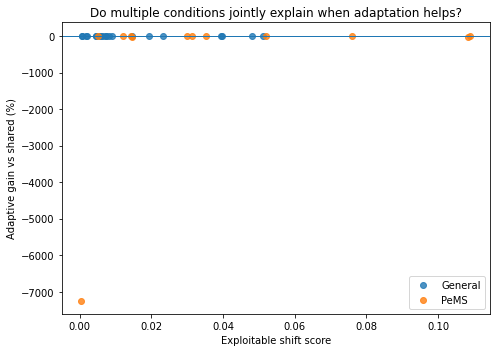

In [19]:
fig, ax = plt.subplots(
    figsize=(
        7,
        5,
    )
)

for family, sub in score_df.groupby(
    "family"
):
    ax.scatter(
        sub[
            "exploitable_shift_score"
        ],
        sub[
            "adaptive_gain_vs_shared_%"
        ],
        label=family,
        alpha=0.8,
    )

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xlabel(
    "Exploitable shift score"
)

ax.set_ylabel(
    "Adaptive gain vs shared (%)"
)

ax.set_title(
    "Do multiple conditions jointly explain when adaptation helps?"
)

ax.legend()

plt.tight_layout()
plt.show()


## 18. Target-level analysis: avoid dataset-average masking


In [20]:
target_corr = (
    all_rows[
        [
            "dependency_drift",
            "predictive_utility_topk_mean_%",
            "utility_concentration",
            "source_reliability",
            "target_only_test_mse",
            "cross_channel_headroom_%",
            "adaptive_gain_vs_shared_%",
        ]
    ]
    .corr(
        method="spearman"
    )
)

display(
    target_corr.round(
        3
    )
)

target_positive = (
    all_rows
    .assign(
        adaptive_positive=(
            all_rows[
                "adaptive_gain_vs_shared_%"
            ]
            >
            0
        )
    )
    .groupby(
        [
            "family",
            "dataset",
            "horizon",
        ],
        as_index=False,
    )
    .agg(
        target_positive_fraction=(
            "adaptive_positive",
            "mean",
        ),
        mean_adaptive_gain=(
            "adaptive_gain_vs_shared_%",
            "mean",
        ),
        median_adaptive_gain=(
            "adaptive_gain_vs_shared_%",
            "median",
        ),
    )
)

display(
    target_positive.round(
        4
    )
)

target_positive.to_csv(
    OUTPUT_DIR
    / "adaptive_target_positive_fraction.csv",
    index=False,
)


,dependency_drift,predictive_utility_topk_mean_%,utility_concentration,source_reliability,target_only_test_mse,cross_channel_headroom_%,adaptive_gain_vs_shared_%
dependency_drift,1.000,0.190,-0.227,-0.242,0.325,0.237,0.085
predictive_utility_topk_mean_%,0.190,1.000,-0.618,-0.026,-0.038,0.714,0.092
utility_concentration,-0.227,-0.618,1.000,0.382,-0.051,-0.466,-0.087
source_reliability,-0.242,-0.026,0.382,1.000,0.219,-0.082,-0.012
target_only_test_mse,0.325,-0.038,-0.051,0.219,1.000,0.042,-0.032
cross_channel_headroom_%,0.237,0.714,-0.466,-0.082,0.042,1.000,0.206
adaptive_gain_vs_shared_%,0.085,0.092,-0.087,-0.012,-0.032,0.206,1.000


,family,dataset,horizon,target_positive_fraction,mean_adaptive_gain,median_adaptive_gain
0,General,ETTh1,96,0.2857,0.0000,0.0000
1,General,ETTh1,192,0.0000,0.0000,0.0000
2,General,ETTh1,336,0.1429,-0.0000,0.0000
3,General,ETTh1,720,0.0000,-0.0000,0.0000
4,General,ETTm1,96,0.1429,0.0000,0.0000
5,General,ETTm1,192,0.0000,0.0000,0.0000
6,General,ETTm1,336,0.2857,0.0000,0.0000
7,General,ETTm1,720,0.0000,0.0000,0.0000
8,General,Electricity,96,0.4688,-2.0016,-0.7384
9,General,Electricity,192,0.4375,-0.3444,-0.4335


## 19. Automatic interpretation for the paper story


In [21]:
pems = condition_mean[
    condition_mean[
        "family"
    ]
    ==
    "PeMS"
]

general = condition_mean[
    condition_mean[
        "family"
    ]
    ==
    "General"
]

pems_gain = (
    float(
        pems[
            "adaptive_gain_vs_shared_%"
        ].mean()
    )
    if len(
        pems
    )
    else np.nan
)

general_gain = (
    float(
        general[
            "adaptive_gain_vs_shared_%"
        ].mean()
    )
    if len(
        general
    )
    else np.nan
)

print(
    "PeMS mean adaptive gain:",
    f"{pems_gain:+.4f}%"
)

print(
    "General mean adaptive gain:",
    f"{general_gain:+.4f}%"
)

gain_corrs = (
    condition_mean[
        analysis_cols
    ]
    .corr(
        method="spearman"
    )[
        "adaptive_gain_vs_shared_%"
    ]
    .drop(
        "adaptive_gain_vs_shared_%"
    )
    .sort_values(
        ascending=False
    )
)

print(
    "\nCondition-level Spearman correlation with adaptive gain:"
)

display(
    gain_corrs.to_frame(
        "rho"
    ).round(
        3
    )
)

print(
    "\n--- Provisional interpretation ---"
)

if (
    np.isfinite(
        pems_gain
    )
    and
    np.isfinite(
        general_gain
    )
    and
    pems_gain > 0
    and
    general_gain <= 0
):
    print(
        "The controlled diagnostic reproduces the key empirical asymmetry:"
    )

    print(
        "horizon-adaptive source selection helps PeMS on average, "
        "but does not generalize as a universal rule."
    )

    print(
        "The next paper question should therefore be conditional: "
        "which measurable properties distinguish exploitable horizon shifts "
        "from merely changing dependencies?"
    )

elif (
    np.isfinite(
        pems_gain
    )
    and
    np.isfinite(
        general_gain
    )
    and
    pems_gain > general_gain
):
    print(
        "PeMS shows a larger adaptive-selection benefit than the general datasets."
    )

    print(
        "This supports analyzing predictive utility, concentration, reliability, "
        "and cross-channel headroom as explanations of the domain gap."
    )

else:
    print(
        "The simple Ridge diagnostic does not reproduce a clear PeMS/general split."
    )

    print(
        "Do not force the paper story. Inspect target-level results and "
        "the individual mechanism metrics before designing a selective router."
    )


PeMS mean adaptive gain: -607.3229%
General mean adaptive gain: -0.4506%

Condition-level Spearman correlation with adaptive gain:


,rho
source_reliability,0.317
target_only_test_mse,0.141
utility_concentration,0.107
cross_channel_headroom_%,0.011
dependency_drift,-0.002
predictive_utility_topk_mean_%,-0.161



--- Provisional interpretation ---
The simple Ridge diagnostic does not reproduce a clear PeMS/general split.
Do not force the paper story. Inspect target-level results and the individual mechanism metrics before designing a selective router.


# 20. How this experiment feeds the paper

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.
